In [1]:
import pandas as pd
import numpy as np
from math import log2

In [2]:
data = [
    ["m","w","a","aaa","to buy"],
    ["e","d","t","am","to buy"],
    ["e","d","a","am","to buy"],
    ["m","w","sw","am","to buy"],
    ["m","w","sw","eu","to buy"],
    ["m","d","t","eu","not to buy"],
    ["e","sp","a","aaa","not to buy"],
    ["b","r","t","eu","not to buy"],
    ["b","d","a","aaa","not to buy"],
    ["m","d","b","aaa","not to buy"]
]

columns = ["Price","Type","Characteristic","Origin","Decision"]

df = pd.DataFrame(data, columns=columns)
df

,Price,Type,Characteristic,Origin,Decision
0,m,w,a,aaa,to buy
1,e,d,t,am,to buy
2,e,d,a,am,to buy
3,m,w,sw,am,to buy
4,m,w,sw,eu,to buy
5,m,d,t,eu,not to buy
6,e,sp,a,aaa,not to buy
7,b,r,t,eu,not to buy
8,b,d,a,aaa,not to buy
9,m,d,b,aaa,not to buy


In [3]:
# Entropy Function

In [4]:
def entropy(series):
    values = series.value_counts()
    total = len(series)
    
    ent = 0
    for v in values:
        p = v / total
        ent -= p * log2(p)
    return ent


In [5]:
# Calculation of Parent Entropy 

In [6]:
parent_entropy = entropy(df["Decision"])
parent_entropy


1.0

In [7]:
# Knowledge Gain for the Species

In [8]:
def information_gain(data, feature, target="Decision"):
    total_entropy = entropy(data[target])
    
    values = data[feature].unique()
    weighted_entropy = 0
    
    for v in values:
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset) / len(data)) * entropy(subset[target])
    
    ig = total_entropy - weighted_entropy
    return ig, weighted_entropy

ig_type, weighted_entropy_type = information_gain(df, "Type")

ig_type, weighted_entropy_type


(0.5145247027726657, 0.4854752972273343)

In [9]:
# Type = subset d → next split

In [10]:
df_d = df[df["Type"] == "d"]
df_d


,Price,Type,Characteristic,Origin,Decision
1,e,d,t,am,to buy
2,e,d,a,am,to buy
5,m,d,t,eu,not to buy
8,b,d,a,aaa,not to buy
9,m,d,b,aaa,not to buy


In [11]:
entropy_d = entropy(df_d["Decision"])
entropy_d


0.9709505944546686

In [19]:
ig_price_d, _ = information_gain(df_d, "Price")
ig_price_d       #price entropy


0.9709505944546686

In [18]:
ig_origin_d, _ = information_gain(df_d, "Origin")
ig_origin_d   #origin entropy 


0.9709505944546686

In [17]:
ig_char_d, _ = information_gain(df_d, "Characteristic")
ig_char_d    # characteristic entropy


0.17095059445466854

In [15]:
# Markdown cell 

In [16]:
# Parent entropy is 1.0, since the dataset is perfectly balanced.

#The information gain for splitting on the attribute "Type" is approximately 0.5145.

#After splitting by Type, only the subset with Type = d is not pure.  
#For this subset, both Price and Origin give the same maximum information gain (0.97095), producing pure leaf nodes.

#Therefore, the next split attribute is not unique. Either Price or Origin can be chosen.


In [20]:
# TASK 2 Use the K-means clustering algorithm to perform a segmentation of the provided data.

In [2]:
import pandas as pd

df = pd.read_csv("D:\Desktop\Task2_Data_Clustering.csv")
df.head()


,Feature1,Feature2,Feature3,Feature4
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
df.columns = ["SepalLength", "SepalWidth", "PetalLength", "PetalWidth"]


In [4]:
df.shape


(150, 4)

In [5]:
df.isna().sum()


SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
dtype: int64

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


In [7]:
# we choose k – Elbow Method + Silhouette Score

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))


C:\Users\Tuna\Documents\anacoonda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tuna\Documents\anacoonda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tuna\Documents\anacoonda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tuna\Documents\anacoonda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

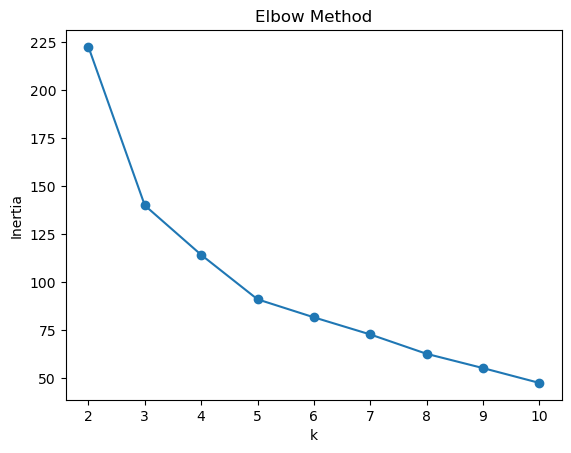

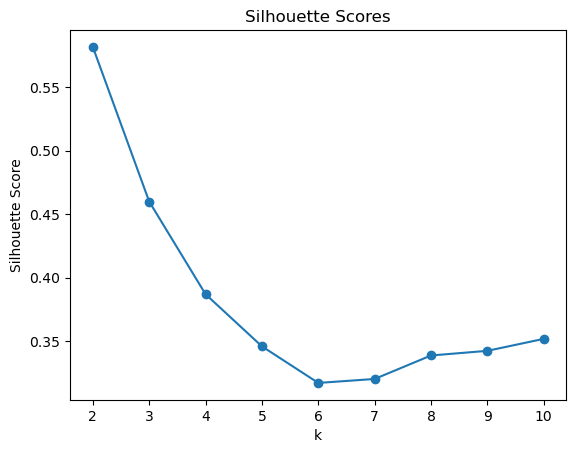

In [9]:
import matplotlib.pyplot as plt

# Elbow plot
plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette plot
plt.figure()
plt.plot(list(K_range), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()


In [10]:
# Task 3 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [12]:
df = pd.read_csv("D:\Desktop\Task3_Data_Process.csv")  # my file name 

print(df.shape)
df.head()


(25, 2)


,x,y
0,0.287578,1.164440
1,0.788305,-0.887802
2,0.408977,0.174131
3,0.883017,-0.217437
4,0.940467,-0.076454


In [13]:
df.isna().sum(), df["x"].min(), df["x"].max()


(x    0
 y    0
 dtype: int64,
 0.04205953,
 0.99426978)

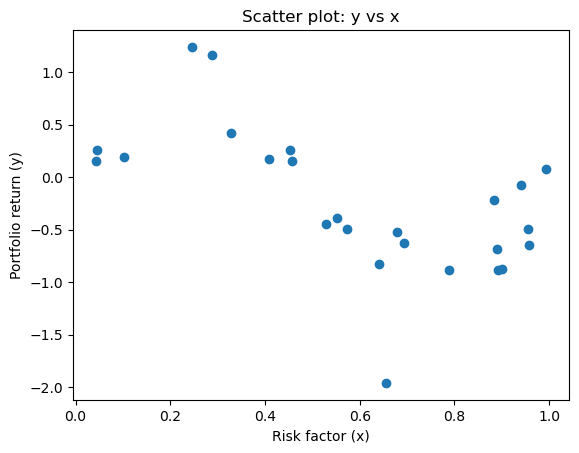

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["x"], df["y"])
plt.xlabel("Risk factor (x)")
plt.ylabel("Portfolio return (y)")
plt.title("Scatter plot: y vs x")
plt.show()


In [15]:
from sklearn.model_selection import train_test_split

X = df[["x"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((20, 1), (5, 1))

In [16]:
# Lineer Regression 

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear regression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)


y_pred_lin = lin_model.predict(X_test)


mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

mae_lin, mse_lin, r2_lin


NameError: name 'X_train' is not defined

In [18]:
# Polynomial degree = 2

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly2 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lr", LinearRegression())
])

poly2.fit(X_train, y_train)
y_pred_p2 = poly2.predict(X_test)

mae_p2 = mean_absolute_error(y_test, y_pred_p2)
mse_p2 = mean_squared_error(y_test, y_pred_p2)
r2_p2 = r2_score(y_test, y_pred_p2)

mae_p2, mse_p2, r2_p2


(0.8018221099995723, 0.8439567152198967, -1.0928652752538306)

In [20]:
# Polynomial Degree = 3 

In [21]:
poly3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("lr", LinearRegression())
])

poly3.fit(X_train, y_train)
y_pred_p3 = poly3.predict(X_test)

mae_p3 = mean_absolute_error(y_test, y_pred_p3)
mse_p3 = mean_squared_error(y_test, y_pred_p3)
r2_p3 = r2_score(y_test, y_pred_p3)

mae_p3, mse_p3, r2_p3


(0.3776391811651965, 0.21480492148560176, 0.4673213056741812)

In [22]:
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial (deg=2)", "Polynomial (deg=3)"],
    "MAE": [mae_lin, mae_p2, mae_p3],
    "MSE": [mse_lin, mse_p2, mse_p3],
    "R2": [r2_lin, r2_p2, r2_p3]
})

results


,Model,MAE,MSE,R2
0,Linear,0.783023,0.820793,-1.035424
1,Polynomial (deg=2),0.801822,0.843957,-1.092865
2,Polynomial (deg=3),0.377639,0.214805,0.467321


C:\Users\Tuna\Documents\anacoonda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


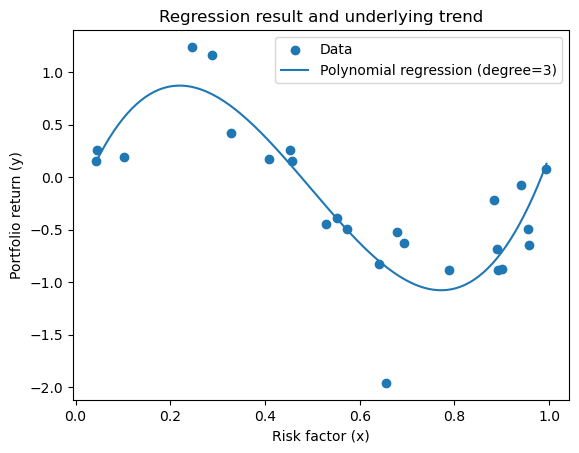

In [23]:
# we choose polynomial degree = 3 model for this assignment 
final_model = poly3

# Let's retrain on all the data.

final_model.fit(X, y)

x_line = np.linspace(df["x"].min(), df["x"].max(), 200).reshape(-1, 1)
y_line = final_model.predict(x_line)

plt.figure()
plt.scatter(df["x"], df["y"], label="Data")
plt.plot(x_line, y_line, label="Polynomial regression (degree=3)")
plt.xlabel("Risk factor (x)")
plt.ylabel("Portfolio return (y)")
plt.title("Regression result and underlying trend")
plt.legend()
plt.show()
